In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbHVjYS9Eb2t1bWVudGUvZGV2L2FyYmVpdC9sdWNhaC50ZWNoL3F1b3RlbWUuZ2l0aHViLmlvL3Bvc3RzL2Nhbi10aGUtY292YXJpYW5jZS1tYXRyaXgtaGF2ZS1pbWFnaW5hcnktZWlnZW52ZWN0b3Jz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/importlib/_bootstrap.py": 1746706798.1099684, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/importlib/_bootstrap_external.py": 1746706798.1109684, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/zipimport.py": 1746706798.599966, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/codecs.py": 1746706797.6719706, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/aliases.py": 1746706797.7389703, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/__init__.py": 1746706797.7359703, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/utf_8.py": 1746706797.79997, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/abc.py": 1746706797.6389706, "/home/luca/.local/sh

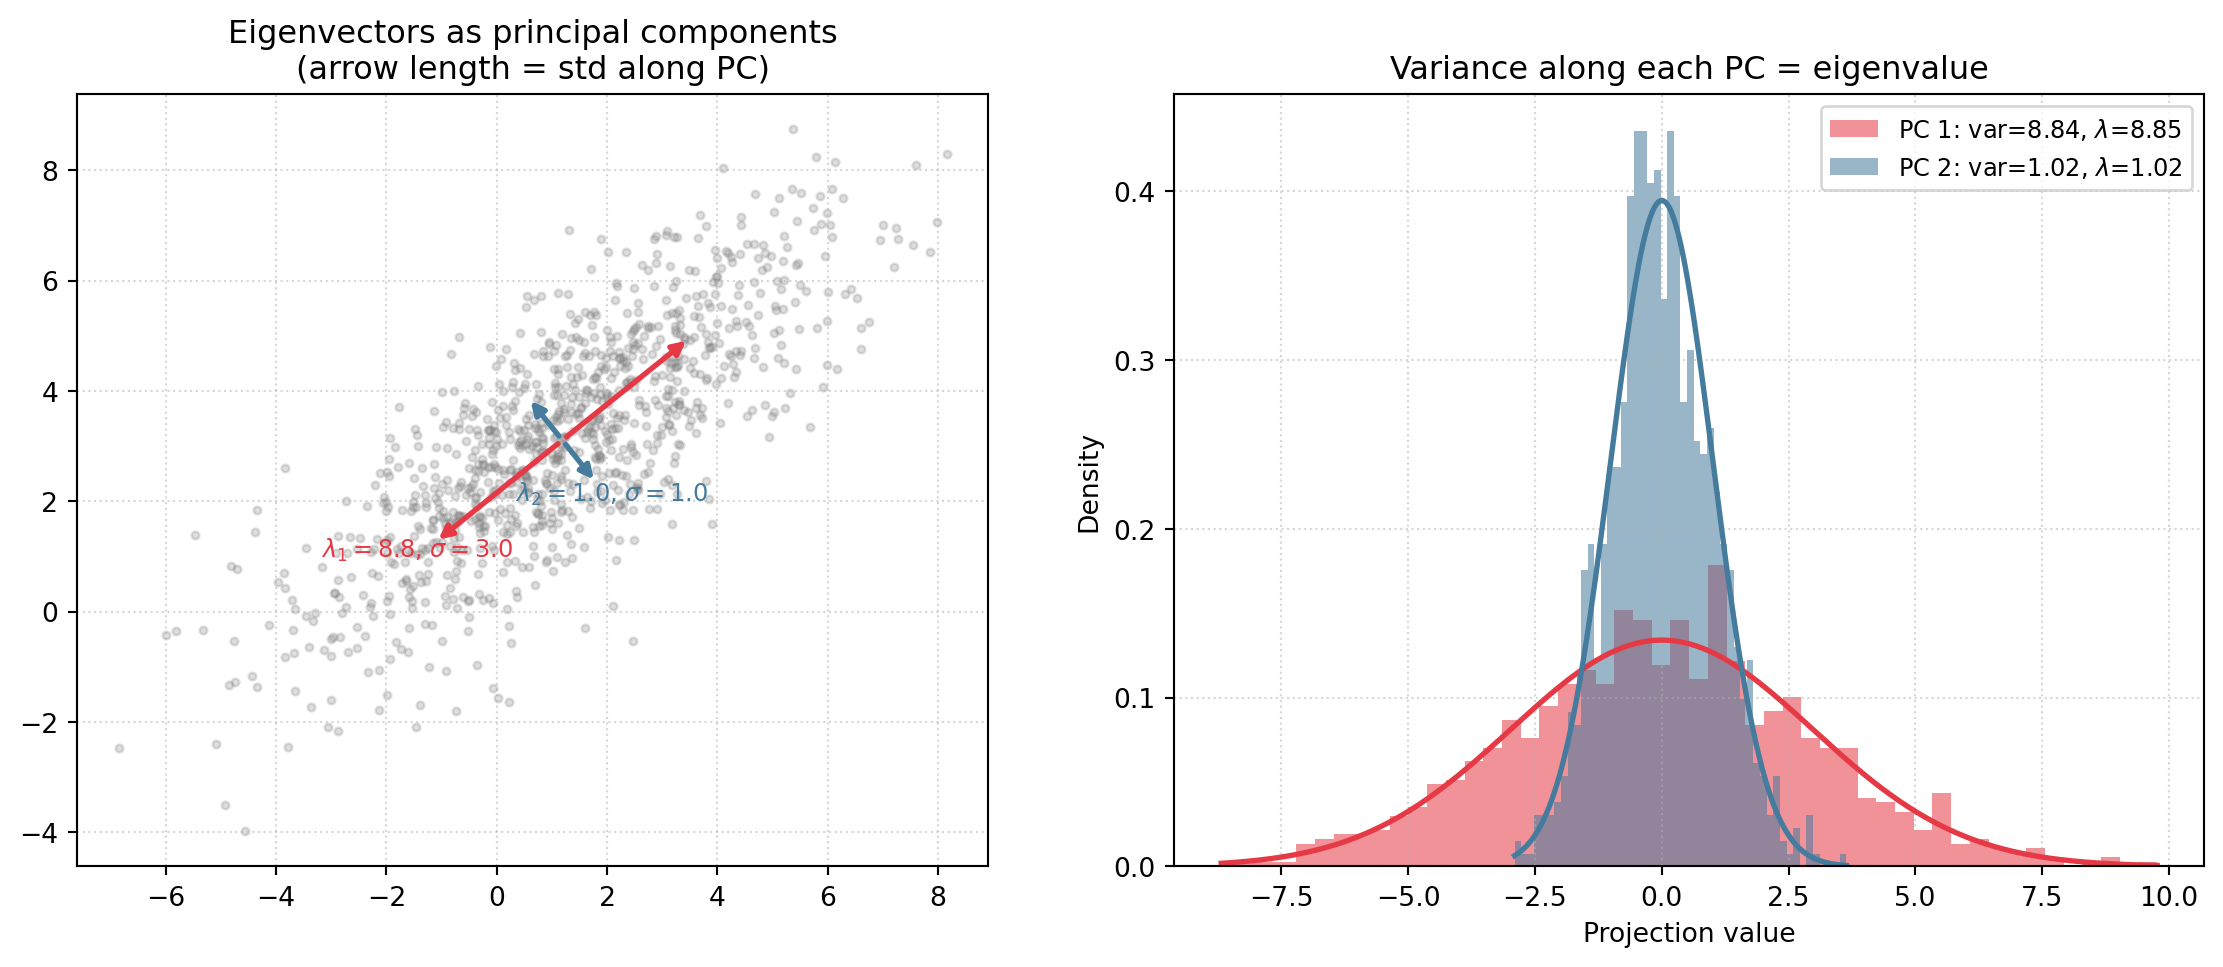

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)

angle = np.radians(40)
R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
X = rng.multivariate_normal([1, 3], R @ np.diag([9, 1]) @ R.T, size=1000)

eigenvalues, eigenvectors = np.linalg.eigh(np.cov(X.T))
eigenvalues, eigenvectors = eigenvalues[::-1], eigenvectors[:, ::-1]
mean = X.mean(axis=0)
colors = ["#e63946", "#457b9d"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X[:, 0], X[:, 1], alpha=0.25, s=8, color="gray")
for i, (lam, vec, c) in enumerate(zip(eigenvalues, eigenvectors.T, colors)):
    std = np.sqrt(lam)
    arrow_kw = dict(arrowstyle="-|>", lw=2, color=c)
    ax1.annotate("", xy=mean + std * vec, xytext=mean, arrowprops=arrow_kw)
    ax1.annotate("", xy=mean - std * vec, xytext=mean, arrowprops=arrow_kw)
    ax1.text(*(mean + (std + 0.4) * vec), rf"$\lambda_{i+1}={lam:.1f}$, $\sigma={std:.1f}$",
             color=c, fontsize=9, ha="center")
ax1.set_aspect("equal")
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.set_title("Eigenvectors as principal components\n(arrow length = std along PC)")

projections = (X - mean) @ eigenvectors
for i, (lam, c) in enumerate(zip(eigenvalues, colors)):
    proj = projections[:, i]
    xs = np.linspace(proj.min(), proj.max(), 300)
    ax2.hist(proj, bins=50, alpha=0.55, color=c, density=True,
             label=rf"PC {i+1}: var={proj.var():.2f}, $\lambda$={lam:.2f}")
    ax2.plot(xs, norm.pdf(xs, scale=np.sqrt(lam)), color=c, lw=2)
ax2.set(xlabel="Projection value", ylabel="Density",
        title="Variance along each PC = eigenvalue")
ax2.legend(fontsize=9)
ax2.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import plotly.graph_objects as go

rng = np.random.default_rng(42)
COLORS = ["#e63946", "#457b9d", "#2a9d8f"]

def add_pca_arrows(fig, X):
    vals, vecs = np.linalg.eigh(np.cov(X.T))
    vals, vecs = vals[::-1], vecs[:, ::-1]
    mean = X.mean(axis=0)
    for i, (lam, vec, c) in enumerate(zip(vals, vecs.T, COLORS)):
        scale = np.sqrt(lam)
        for sign in [1, -1]:
            end = mean + sign * scale * vec
            fig.add_trace(go.Scatter3d(
                x=[mean[0], end[0]], y=[mean[1], end[1]], z=[mean[2], end[2]],
                mode="lines", line=dict(color=c, width=6),
                showlegend=(sign == 1), name=f"PC {i+1} (λ={lam:.2f})"
            ))
            fig.add_trace(go.Cone(
                x=[end[0]], y=[end[1]], z=[end[2]],
                u=[sign * 0.3 * vec[0]], v=[sign * 0.3 * vec[1]], w=[sign * 0.3 * vec[2]],
                colorscale=[[0, c], [1, c]], showscale=False, showlegend=False,
                sizemode="absolute", sizeref=0.4
            ))

layout_kw = dict(margin=dict(l=0, r=0, t=40, b=0), scene=dict(aspectmode="data"))

# Plot 1: 3D Gaussian blob
cov3 = np.array([[4, 2, 0.5], [2, 3, 1], [0.5, 1, 1]])
X1 = rng.multivariate_normal([0, 0, 0], cov3, size=800)

fig1 = go.Figure(layout=layout_kw)
fig1.add_trace(go.Scatter3d(x=X1[:,0], y=X1[:,1], z=X1[:,2], mode="markers",
    marker=dict(size=2, color="#555", opacity=0.5), name="samples"))
add_pca_arrows(fig1, X1)
fig1.update_layout(title="3D Gaussian blob with principal components")
fig1.show()

# Plot 2: xz Gaussian blob with bell-curve bump in y
xz = rng.multivariate_normal([0, 0], [[4, 1], [1, 2]], size=800)
x2, z2 = xz[:, 0], xz[:, 1]
y2 = 2.5 * np.exp(-(x2**2 + z2**2) / 5) + rng.normal(0, 0.1, len(x2))
X2 = np.column_stack([x2, y2, z2])

fig2 = go.Figure(layout=layout_kw)
fig2.add_trace(go.Scatter3d(x=X2[:,0], y=X2[:,1], z=X2[:,2], mode="markers",
    marker=dict(size=2, color="#555", opacity=0.5), name="samples"))
add_pca_arrows(fig2, X2)
fig2.update_layout(title="xz Gaussian blob with bell-curve bump along y: falls short")
fig2.show()

In [4]:
import quaternion

def iota(x, y, z):
    return x * quaternion.x + y * quaternion.y + z * quaternion.z

X1_quat = np.array([iota(*p) for p in X1])
cov_quat = X1_quat[:, np.newaxis] * X1_quat[np.newaxis, :]